# EDA и рассчёт метрик

**Задачи данного ноутбука:**
1) Рассчитать показатели конверсии по этапам воронки, охвата и вовлечённости;
2) Выявить корреляции между переменными;
3) Найти и проанализировать, возможно разделить на группы тайтлы с наилучшей комбинацией метрик.

В датасете есть в том числе готовые показатели охвата - `details.members`, `stats.total`, `stats.watching`, `details.scored_by`, а также показатели вовлечённости - `details.favourites` и средняя оценка `details.score`.

Этот ноутбук выполняет одну из главных задач данного проекта - выявить тренды в сегменте аниме сериалов. 

## Setup

In [58]:
import ast #для распаковки значений типа ['Action', 'Adventure']
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent #чтобы доставать данные и функции
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import duckdb #чтобы обращаться напрямую к ratings на sql
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from src.functions import fancy_info # аналог info() с подсветкой ячеек с большим % пропусков

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_theme(style='darkgrid')

#### details и stats

Применим правила, к которым пришли в `01_data_quality`

*Из `details` выброшены `title_japanese`, `url`, `image_url`, `producers`, `licensors`, `streaming`, `explicit_genres`.  
В качестве даты выхода взята `start_date` а не `year`.  
В `ratings` - `NULLIF(score, 0)`, `num_watched_episodes > 3000` тоже NULL, исключены тайтлы со статусом `unknown` (0.01%).  
При inner join `ratings` × `details` 326 аниме без карточки отваливаются (0.25% строк).*

In [59]:
RAW = PROJECT_ROOT / 'data' / 'raw'

details = pd.read_csv(RAW / 'details.csv', sep=',')
stats = pd.read_csv(RAW / 'stats.csv', sep=',')

details = details.drop(['title_japanese', 'url', 'image_url', 'producers',
                        'licensors', 'streaming', 'explicit_genres'], axis=1) 

for col in ['type', 'status', 'genres', 'themes', 'source', 'rating', 'studios']:
    details[col] = details[col].astype('string') # преобразуем значения типа ['Action', 'Adventure'] в pd.StringDtype

details['start_date'] = pd.to_datetime(details['start_date'], errors='coerce') # преобразуем start_date в котором сейчас строка в datetime64
details['start_year'] = details['start_date'].dt.year # создадим столбец с годом выхода отдельно

print(details.shape, stats.shape)

(28955, 23) (28955, 27)


#### джойн details + stats

`mal_id` уникален в обеих таблицах и наборы ключей совпадают в обе стороны.

In [61]:
anime = details.merge(stats, on='mal_id')

print(anime.shape)
fancy_info(anime)

(28955, 49)


,column,dtype,non_null_count,null_percent
0,mal_id,int64,28955,0.00
1,title,str,28955,0.00
2,type,string,28888,0.23
3,status,string,28955,0.00
4,score,float64,18882,34.79
5,scored_by,float64,18882,34.79
6,start_date,"datetime64[us, UTC]",28104,2.94
7,end_date,str,11267,61.09
8,synopsis,str,23828,17.71
9,rank,float64,21997,24.03


Опять же, вернёмся к данным вида `"['Action', 'Comedy']"`. Для разрезов по жанрам, темам, возрастным рейтингам и т п такую строку нужно разобрать в список. Пустой список `[]` при разрезах будем считать отдельной категорией.

In [62]:
def to_list(s):
    """'[\"Action\", \"Comedy\"]' -> ['Action', 'Comedy'], пропуск/пустая строка -> []"""
    if pd.isna(s): # если значение NaN — сразу пустой список
        return []
    if isinstance(s, list):  # если это уже список — вернуть как есть
        return s
    try: 
        # пробуем распарсить строку как питоновский литерал:
        val = ast.literal_eval(s)
    except (ValueError, SyntaxError): 
        # если строка не парсится ( пустая строка или битый формат) — тоже пустой список
        return []
    # если распарсилось в список или кортеж — привести к списку; если в одиночное значение (не список) — обернуть в список
    return list(val) if isinstance(val, (list, tuple)) else [val]

for col in ['genres', 'themes', 'studios']:
    anime[f'{col}_list'] = anime[col].map(to_list)

print(anime[['genres_list', 'themes_list', 'studios_list']].dtypes)

# сколько тайтлов имеют непустой список
anime[['genres_list', 'themes_list', 'studios_list']].map(len).gt(0).mean().mul(100).round(1).to_frame('% непустых')

genres_list     object
themes_list     object
studios_list    object
dtype: object


,% непустых
genres_list,79.3
themes_list,59.2
studios_list,59.6


#### ratings

Поверх сырой `ratings` делаем view `ratings_clean`, как и в прошлом ноутбуке.
- `score = 0` - `NULL` это значит «не оценил»;
- `num_watched_episodes > 3000` - `NULL`, но саму строку не выбрасываем;
- статус `unknown` исключён (0.01%);
- inner join с `details` по `anime_id = mal_id`.

In [63]:
con = duckdb.connect()
con.execute("SET enable_progress_bar=false") # для эстетики

parquet_path = (RAW / 'ratings.parquet').as_posix() # конвертирует Path в строку с прямыми слэшами /. DuckDB ждёт именно прямые слэши
con.sql(f"CREATE VIEW ratings AS SELECT * FROM read_parquet('{parquet_path}')")

# регистрируем в duckdb таблицу anime под именем anime_meta
con.register('anime_meta', anime)

con.sql("""
CREATE VIEW ratings_clean AS
SELECT
    r.username,
    r.anime_id,
    r.status,
    NULLIF(r.score, 0) AS score,                            -- 0 = «не оценил»
    CASE WHEN r.num_watched_episodes <= 3000                -- 65535 = заглушка парсера
         THEN r.num_watched_episodes END AS episodes_watched
FROM ratings r
JOIN anime_meta a ON r.anime_id = a.mal_id                  -- отсекаем 326 аниме без карточки
WHERE r.status <> 'unknown' AND r.status <> ''              -- отсекаем аниме без статуса
""")

def q(sql):
    """Запрос к duckdb с результатом в pandas."""
    return con.sql(sql).df()

q("""
SELECT (SELECT count(*) FROM ratings)                          AS сырых_строк,
       (SELECT count(*) FROM ratings_clean)                    AS после_фильтров,
       (SELECT count(*) FROM ratings_clean WHERE score IS NOT NULL) AS строк_с_оценкой,
       (SELECT count(DISTINCT username) FROM ratings_clean)    AS пользователей,
       (SELECT count(DISTINCT anime_id) FROM ratings_clean)    AS тайтлов
""")

,сырых_строк,после_фильтров,строк_с_оценкой,пользователей,тайтлов
0,124298357,123973944,69459288,309286,28945


Итого для анализа есть две сущности:

- `anime` (pandas) — одна строка на тайтл, все признаки `details` + распределение статусов и голосов из `stats`;
- `ratings_clean` (duckdb view) — взаимодействия пользователя с тайтлом, для метрик удержания и глубины просмотра.

Критерий `is_rewatching` не берём т к 1.0 есть лишь у 0.08% строк, и непонятно, откуда MAL мог бы точно знать о пересмотре.

## Рассчёт показателей воронки

Считать метрики будем только по тайтлам со статусом `Finished Airing`. У `Currently Airing` и `Not yet aired` воронка ещё не закрыта: досмотреть их физически нельзя, поэтому `completed` занижен, а `watching`/`plan_to_watch` раздуты - такие тайтлы выглядят как «все бросили» и портят любые доли.

Обозначим следующие признаки:
- `started` - начатые тайтлы, то есть имеющие статусы watching, completed, dropped, on_hold. Stats.total включает в себя тайтлы с данными статусами + plan_to_watch и показывает, сколько человек вообще знает аниме, а started будет отражать именно начат ли просмотр.

- `conversion_to_start` - сколько из планирующих просмотр до него дошли, первый этап воронки, `started / total`. Тут стоит оглядываться на дату выпуска, у старых аниме данная конверсия лучше, а у новых может быть большой plan_to_watch и маленький started. 

- `completion_rate` - индикатор завершения просмотра. Всего для просмотра аниме есть 2 варианта исхода - досмотреть или бросить. Долю досмотренных можно посчитать как `completed / (completed + dropped)`. Важный поинт здесь - далеко не все пользователи отмечают заброшенные аниме, думаю, очень часто они остаются лежать в watching, то есть dropped естественным образом довольно сильно занижен, а `completion_rate` будет завышен. Тем не менее, если сравнивать относительно этого критерия, учитывая, что все значения завышены - будет ок. 
Также не имеет смысла брать в этот показатель полнометражные movie так как у них автоматически досматриваемость намного выше сериала.  

- `drop_rate` - доля явно отказавшихся от просмотра от начавших, т е `dropped / started`. Не равно `1 − completion_rate` т к в знаменателе есть watching и on_hold.

- `favorites_rate` - показатель привязанности `favorites / members`
- `scoredby_rate` - какая доля пользователей из members поставили оценку - scored_by / members. Показатель полноты score. Если оценивших мало относительно аудитории — средняя оценка имеет маленький вес как критерий.

In [64]:
def safe_div(a, b):
    """Деление с NaN там, где знаменатель 0."""
    return a / b.replace(0, np.nan)

# распределение по статусам, чтобы понять долю завершённых
print(anime['status'].value_counts())

# только завершённые тайтлы: у остальных воронка ещё не закрыта
finished = anime[anime['status'] == 'Finished Airing'].copy()
print(f'\nзавершённых: {len(finished)} из {len(anime)} = {round(len(finished)/len(anime)*100, 2)}%')

# сколько людей реально начали смотреть — сумма всех статусов кроме plan_to_watch
finished['started'] = finished[['watching', 'completed', 'dropped', 'on_hold']].sum(axis=1)

# доля от общего total, кто дошёл хотя бы до старта просмотра
finished['conversion_to_start'] = safe_div(finished['started'], finished['total'])
# доля закончивших среди тех, у кого воронка закрыта (закончил или бросил)
# ПЕРЕДЕЛАЛА drop здесь нахуй не нужен т к это вообще используется в финальном сравнении
finished['completion_rate'] = safe_div(finished['completed'], finished['total'])
# доля бросивших среди начавших смотреть - метрика оттока
finished['drop_rate'] = safe_div(finished['dropped'], finished['started'])
# доля добавивших в избранное среди всех, кто знает о тайтле (members) - тоже метрика вовлечённости
finished['favorites_rate'] = safe_div(finished['favorites'], finished['members'])
# доля оценивших от members
finished['scoredby_rate'] = safe_div(finished['scored_by'], finished['members'])

metrics = ['conversion_to_start', 'completion_rate', 'drop_rate',
           'favorites_rate', 'scoredby_rate']

# посмотрим первые 10 строк с метриками для проверки
conversion_df = finished[['mal_id', 'title', 'type', 'start_year', 'total', 'started'] + metrics]
conversion_df.head(10)

status
Finished Airing     28097
Not yet aired         544
Currently Airing      314
Name: count, dtype: int64[pyarrow]

завершённых: 28097 из 28955 = 97.04%


,mal_id,title,type,start_year,total,started,conversion_to_start,completion_rate,drop_rate,favorites_rate,scoredby_rate
0,59356,-Socket-,Movie,2010.0,197,177,0.898477,0.741117,0.112994,0.000000,NaN
1,56036,......,Music,2023.0,941,828,0.879915,0.818278,0.035024,0.002125,0.534538
2,2928,.hack//G.U. Returner,OVA,2007.0,22527,16055,0.712700,0.663781,0.021738,0.001376,0.432630
3,3269,.hack//G.U. Trilogy,Movie,2007.0,34267,24505,0.715120,0.665071,0.021914,0.003035,0.448663
4,4469,.hack//G.U. Trilogy: Parody Mode,Special,2008.0,11135,7607,0.683161,0.621284,0.034968,0.000898,0.387696
5,454,.hack//Gift,OVA,2003.0,21457,16430,0.765717,0.718693,0.025746,0.000932,0.467005
6,1143,.hack//Intermezzo,Special,2003.0,24342,18495,0.759798,0.719333,0.017464,0.000288,0.477239
7,299,.hack//Liminality,OVA,2002.0,34987,27483,0.785520,0.699631,0.036313,0.001000,0.489624
8,9332,.hack//Quantum,OVA,2011.0,42223,31471,0.745352,0.686758,0.021703,0.001705,0.483502
9,10390,.hack//Quantum: Sore ike! Bokura no Chimuchimu...,Special,2011.0,8836,5349,0.605364,0.525464,0.054777,0.000340,0.318053


У тайтлов с крошечной аудиторией доли дают слишком большие скачки, поэтому для разрезов берём только те, где `started >= 1000`. Разрез по `type` подтверждает оговорку выше: у `movie` completion_rate заведомо выше.

In [65]:
popular = finished[finished['started'] >= 1000] 

print(f'тайтлов со started >= 1000: {len(popular)} из {len(finished)}')

# сводка по новым показателям
display(popular[metrics].describe().round(3))

# группировка по типу 
display(
    popular.groupby('type', observed=True)
           .agg(тайтлов=('mal_id', 'count'),
                **{m: (m, 'median') for m in metrics})
           .round(3)
           .sort_values('тайтлов', ascending=False)
)

# на всякий случай добавим флажок is_popular в нашу новую таблицу с метриками
conversion_df['is_popular'] = conversion_df['started'] >= 1000

тайтлов со started >= 1000: 12664 из 28097


,conversion_to_start,completion_rate,drop_rate,favorites_rate,scoredby_rate
count,12664.000,12664.000,12664.000,12664.000,12663.000
mean,0.688,0.555,0.065,0.003,0.408
std,0.124,0.163,0.054,0.005,0.106
min,0.052,0.022,0.001,0.000,0.019
25%,0.611,0.448,0.027,0.001,0.338
50%,0.696,0.551,0.053,0.002,0.405
75%,0.776,0.671,0.087,0.004,0.481
max,0.978,0.967,0.581,0.073,0.899


,тайтлов,conversion_to_start,completion_rate,drop_rate,favorites_rate,scoredby_rate
type,,,,,,
TV,4534,0.673,0.491,0.086,0.003,0.398
OVA,2921,0.703,0.545,0.052,0.002,0.391
Movie,1744,0.683,0.616,0.026,0.001,0.444
ONA,1275,0.686,0.516,0.057,0.002,0.370
Special,1119,0.708,0.633,0.028,0.001,0.407
Music,437,0.859,0.810,0.024,0.001,0.550
TV Special,425,0.720,0.643,0.028,0.001,0.426
CM,135,0.717,0.651,0.042,0.001,0.409
PV,74,0.714,0.632,0.035,0.001,0.382


Нас интересуют сериалы (TV), сравнивать их с другими типами не будем, так как конверсия внутри типов сильно отличается. Также для выявления текущих трендов используем границу по дате - только с 2020 года, у них воронка "закрыты" и тренда +- свежие. Позже для анализа трендов можно будет подтянуть незаконченные тайтлы.

In [66]:
conversion_tv_fresh = conversion_df[(conversion_df['type']=='TV') & (conversion_df['start_year'] >= 2020)]
conversion_tv_fresh.shape
display(conversion_tv_fresh)

,mal_id,title,type,start_year,total,started,conversion_to_start,completion_rate,drop_rate,favorites_rate,scoredby_rate,is_popular
19,58985,0-saiji Start Dash Monogatari,TV,2024.0,12275,6660,0.542566,0.226232,0.257658,0.001957,0.206312,True
20,60425,0-saiji Start Dash Monogatari Season 2,TV,2025.0,4389,2257,0.514240,0.324903,0.137350,0.002285,0.246801,True
31,57101,1 Cho,TV,2024.0,1406,323,0.229730,0.039118,0.275542,0.005690,NaN,False
51,41380,100-man no Inochi no Ue ni Ore wa Tatteiru,TV,2020.0,324088,267488,0.825356,0.647818,0.085380,0.002163,0.499685,True
52,44881,100-man no Inochi no Ue ni Ore wa Tatteiru 2nd...,TV,2021.0,182109,145395,0.798395,0.655014,0.045854,0.003515,0.470520,True
...,...,...,...,...,...,...,...,...,...,...,...,...
28892,54112,Zom 100: Zombie ni Naru made ni Shitai 100 no ...,TV,2023.0,644462,527104,0.817898,0.510103,0.069502,0.006525,0.479752,True
28896,55838,Zombie Dumb 3,TV,2022.0,134,94,0.701493,0.253731,0.574468,0.000000,NaN,False
28899,51685,Zombie-ga Doeeo Beorin Naui Ttal,TV,2022.0,4454,935,0.209924,0.054782,0.192513,0.006960,0.050292,False
28904,40174,Zombieland Saga Revenge,TV,2021.0,232666,147382,0.633449,0.493252,0.042970,0.006968,0.404950,True


## Корреляции метрик охвата

Как уже сказано выше - В датасете есть в том числе готовые показатели охвата - `details.members`, `stats.total`, `stats.watching`, `details.scored_by`. Добавим их в общую таблицу.

In [67]:
conversion_tv_fresh = (
    conversion_tv_fresh
    .merge(details[['mal_id', 'members', 'scored_by']], on='mal_id', how='left', validate='1:1')
    .merge(stats[['mal_id', 'watching']], on='mal_id', how='left', validate='1:1')
)

conversion_tv_fresh

,mal_id,title,type,start_year,total,started,conversion_to_start,completion_rate,drop_rate,favorites_rate,scoredby_rate,is_popular,members,scored_by,watching
0,58985,0-saiji Start Dash Monogatari,TV,2024.0,12275,6660,0.542566,0.226232,0.257658,0.001957,0.206312,True,12263,2530.0,1723
1,60425,0-saiji Start Dash Monogatari Season 2,TV,2025.0,4389,2257,0.514240,0.324903,0.137350,0.002285,0.246801,True,4376,1080.0,415
2,57101,1 Cho,TV,2024.0,1406,323,0.229730,0.039118,0.275542,0.005690,NaN,False,1406,NaN,137
3,41380,100-man no Inochi no Ue ni Ore wa Tatteiru,TV,2020.0,324088,267488,0.825356,0.647818,0.085380,0.002163,0.499685,True,324016,161906.0,27006
4,44881,100-man no Inochi no Ue ni Ore wa Tatteiru 2nd...,TV,2021.0,182109,145395,0.798395,0.655014,0.045854,0.003515,0.470520,True,182088,85676.0,15370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1564,54112,Zom 100: Zombie ni Naru made ni Shitai 100 no ...,TV,2023.0,644462,527104,0.817898,0.510103,0.069502,0.006525,0.479752,True,644312,309110.0,130203
1565,55838,Zombie Dumb 3,TV,2022.0,134,94,0.701493,0.253731,0.574468,0.000000,NaN,False,134,NaN,4
1566,51685,Zombie-ga Doeeo Beorin Naui Ttal,TV,2022.0,4454,935,0.209924,0.054782,0.192513,0.006960,0.050292,False,4454,224.0,389
1567,40174,Zombieland Saga Revenge,TV,2021.0,232666,147382,0.633449,0.493252,0.042970,0.006968,0.404950,True,232624,94201.0,19069


Скорее всего для данного случая больше всего подойдёт коэффициент корреляции Спирмена, т к переменные, вероятно, распределены не нормально, содержат рейтинговые оценки и выборка немаленькая. Но для начала проверим линейность зависимостей с помощью диаграммы рассеяния, а также распределения с помощью Шапиро-Уилка

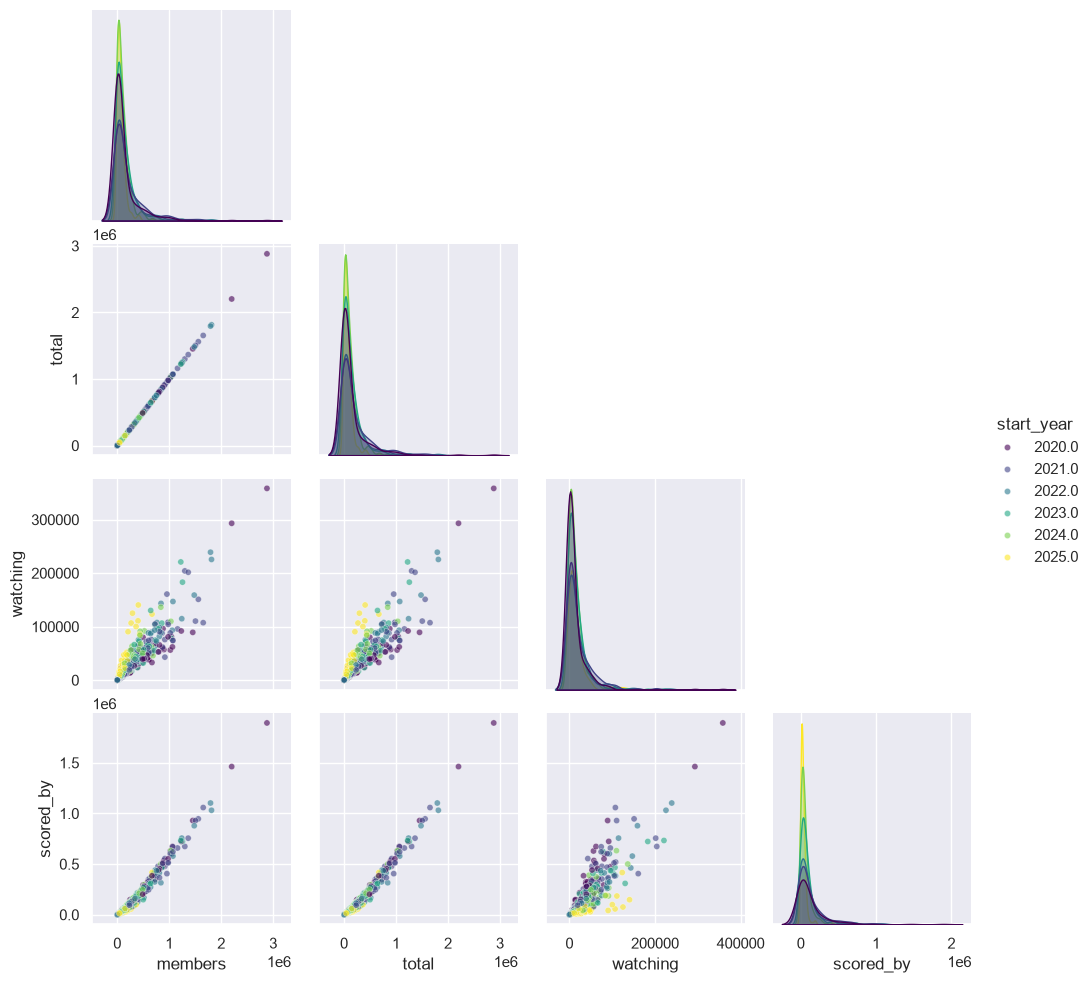

In [68]:
sns.pairplot(
    conversion_tv_fresh,
    vars=['members', 'total', 'watching', 'scored_by'],   # только по предикторам охвата
    hue='start_year',
    palette='viridis',             
    diag_kind='kde',                
    corner=True,                    
    plot_kws={'alpha': 0.6, 's': 20}
)

Уже хорошо видно, что details.members и stats.total - это одно и то же. scored_by и members, а также scored_by и total имеют сильную линейную зависимость. Только watching ведёт себя иначе - разброс широкий, и точки расслоены по годам — у 2024–2025 года выпуска при том же охвате доля смотрящих выше, чем у 2020–2022, поскольку их аудитория ещё не перешла в completed.

In [69]:
# проверим распределения

from scipy.stats import shapiro, skew

rows = []
for x in ['members', 'total', 'watching', 'scored_by']:
    stat, p = shapiro(conversion_tv_fresh[x], nan_policy='omit')
    rows.append({
        'variable': x,
        'stat': stat,
        'p-value': p,
        'skew': skew(conversion_tv_fresh[x], nan_policy='omit'),
        'is_normal': p > 0.05
    })

shapiro_result = pd.DataFrame(rows)
shapiro_result

,variable,stat,p-value,skew,is_normal
0,members,0.574972,5.189844e-52,3.934189,False
1,total,0.575032,5.217890e-52,3.933664,False
2,watching,0.565243,2.177372e-52,4.492202,False
3,scored_by,0.540563,1.246208e-47,4.479221,False


распределения переменных значимо отличаются от нормального (что также подтверждается высокой положительной асимметрией, skew ≈ 4). Это значит, что дальше корректнее использовать корреляцию Спирмена

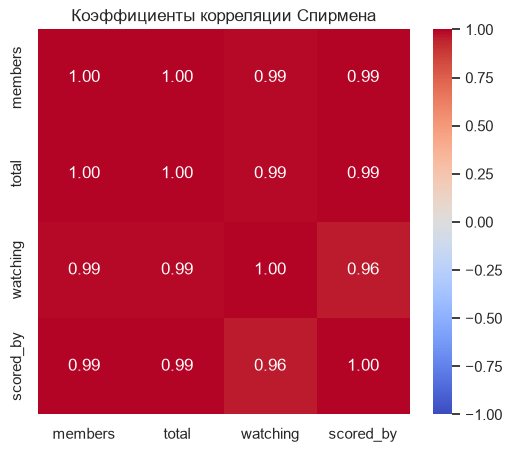

In [70]:
spearman_corr = conversion_tv_fresh[['members', 'total', 'watching', 'scored_by']].corr(method='spearman')
plt.figure(figsize=(6, 5))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Коэффициенты корреляции Спирмена')
plt.show()

Матрица корреляций Спирмена показывает крайне высокую положительную взаимосвязь между всеми переменными (0.96–1.00), что говорит о сильной мультиколлинеарности. Это вполне логично: все четыре метрики отражают разные грани одной и той же характеристики — популярности. Для оценки охвата аудитории целесообразно использовать members — эта метрика показывает общее число пользователей, соприкоснувшихся с тайтлом (вне зависимости от статуса просмотра), в отличие от watching (только текущие зрители) и scored_by (только оценившие), которые отражают более узкие и зависимые от момента среза подмножества аудитории.

## Корреляции показателей воронки

В прошлом блоке все метрики охвата схлопнулись в одну - популярность. С показателями воронки так быть не должно: `conversion_to_start`, `completion_rate`, `drop_rate`, `favorites_rate` и `scoredby_rate` считаются от разных знаменателей и описывают разные этапы. Проверим, действительно ли они несут разный сигнал, или что-то дублируется.

Берём те же пять метрик из `metrics` и только популярные тайтлы (`started >= 1000`) - у мелкой аудитории доли скачут и корреляции получаются шумные. Коэффициент снова Спирмена: это ограниченные доли с перекосами (`favorites_rate` вообще с длинным хвостом), Пирсон тут не релевантен.

тайтлов в разрезе: 1101


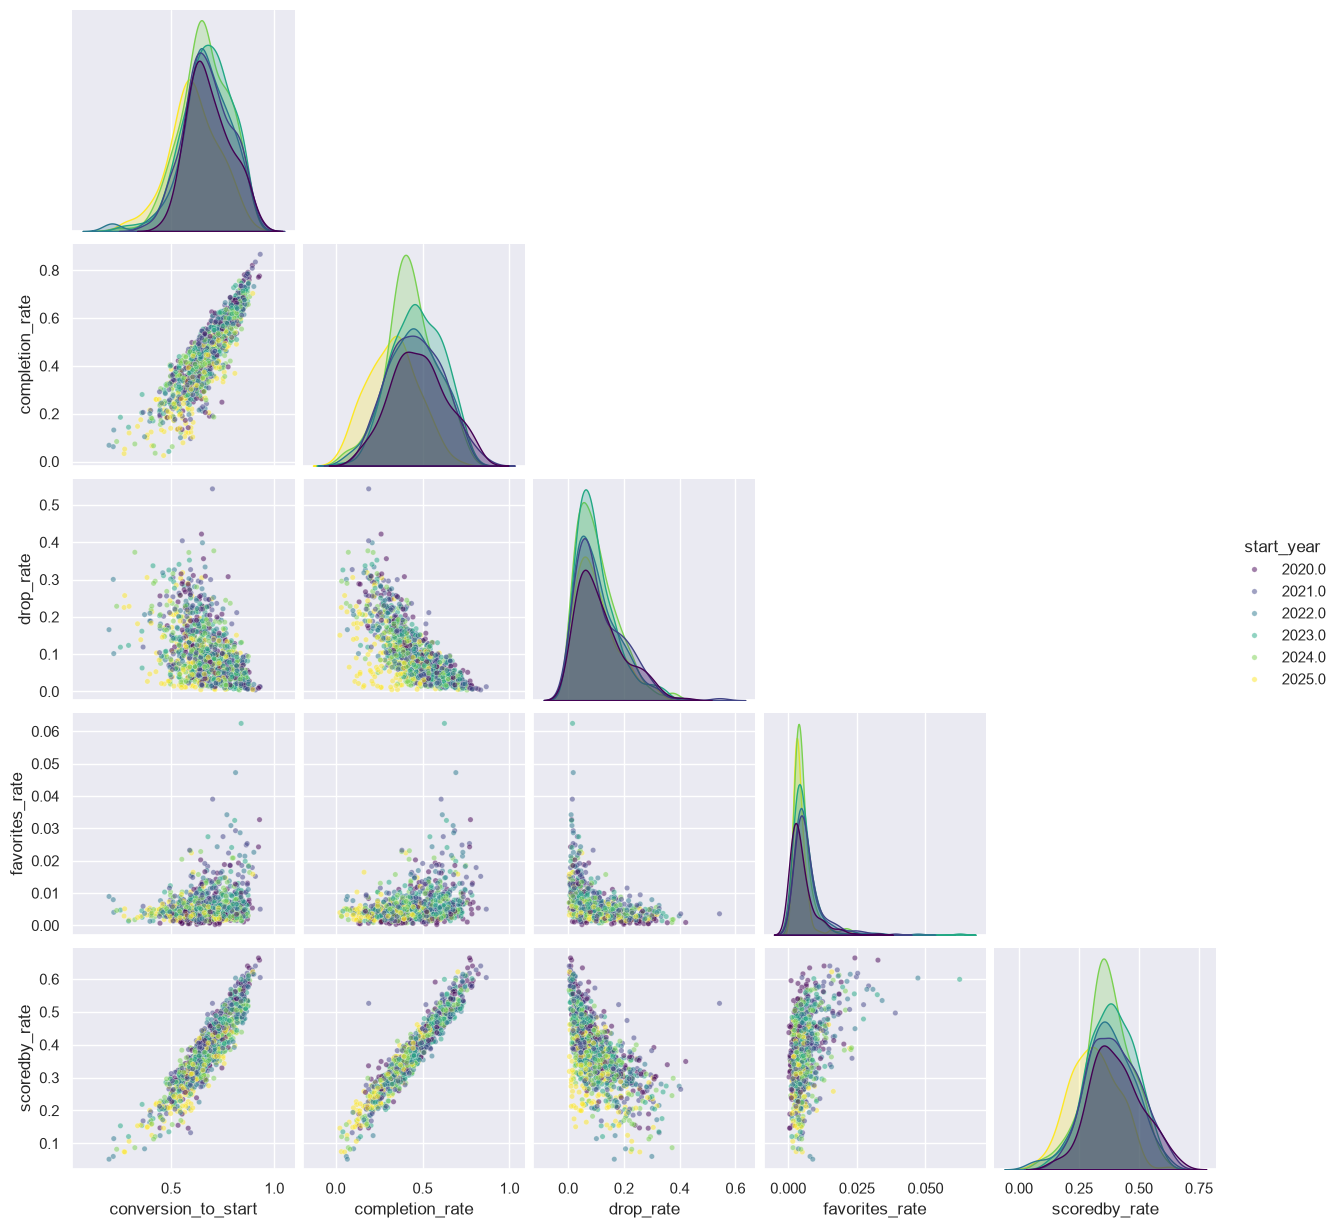

In [71]:
funnel = conversion_tv_fresh[conversion_tv_fresh['is_popular']]   # только популярные (started >= 1000)
print(f'тайтлов в разрезе: {len(funnel)}')

# диаграмма рассеяния
sns.pairplot(
    funnel,
    vars=metrics,
    hue='start_year',
    palette='viridis',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.5, 's': 15}
)

Видно две пары, которые движутся вместе:
- `completion_rate` и `drop_rate` - почти зеркало. Логично: у досмотренного TV-сериала оставшиеся варианты это «досмотрел» или «бросил», так что `completed / (completed + dropped)` и `dropped / started` описывают один и тот же исход с разных сторон.
- `conversion_to_start` и `scoredby_rate` - тоже тянутся друг за другом. По сути обе измеряют, какая доля пришедшей аудитории реально взаимодействовала с аниме, а не просто записала в план.

Выделяется `favorites_rate` - облако размытое, чёткой связи ни с чем нет.  

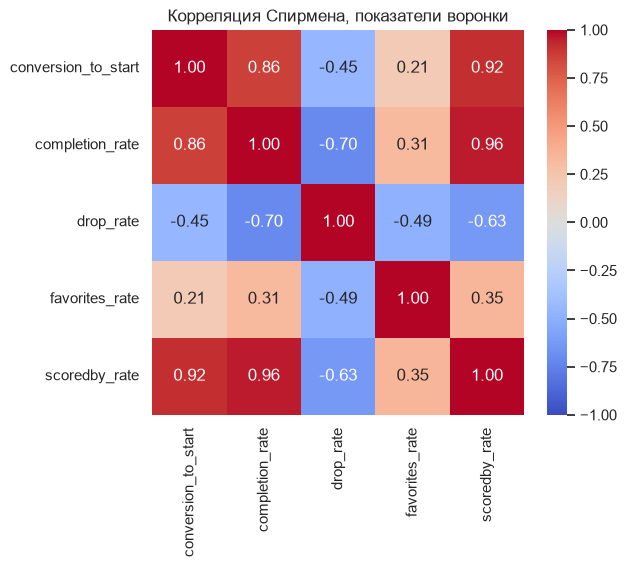

In [72]:
# коэф. корреляции Спирмена
funnel_corr = funnel[metrics].corr(method='spearman')

plt.figure(figsize=(6, 5))
sns.heatmap(funnel_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Корреляция Спирмена, показатели воронки')
plt.show()

Картина не такая, как с охватом: жёсткой мультиколлинеарности нет, метрики в основном про разное.

- `completion_rate` ↔ `drop_rate`: ρ = −0.98, это одно и то же. Оставляем `completion_rate` (читается как «успех»), `drop_rate` убираем.
- `conversion_to_start` ↔ `scoredby_rate`: ρ = 0.92. `scoredby_rate` как отдельный показатель воронки не нужен, но остаётся в проекте в своей роли - как вес для средней оценки (мало оценивших → `score` ненадёжен).
- `completion_rate` и `conversion_to_start`: ρ = 0.50 - связаны, но это разные этапы (начали смотреть / досмотрели), обе оставляем.
- `favorites_rate`: слабые корреляции со всем (|ρ| ≤ 0.49) - отдельная ось, ловит силу привязанности, а не факт досмотра.

Итого для профилирования берём три независимых показателя: `conversion_to_start`, `completion_rate`, `favorites_rate`. По ним и будем искать аниме с лучшей комбинацией метрик в следующем блоке.

## Тайтлы, выигрывающие по вышеуказанным метрикам

В прошлом блоке осталось три независимых показателя: `conversion_to_start` (дошли до просмотра), `completion_rate` (досмотрели), `favorites_rate` (добавили в избранное). «Выигрывающий» тайтл - тот, что хорош по всем трём сразу, а не вытянул за счёт одного.

Сложим их в один балл. Напрямую усреднять нельзя - `completion_rate` это 0.8-0.99, а `favorites_rate` 0.001-0.06, среднее будет полностью про completion. Поэтому переводим каждую метрику в перцентиль внутри выборки и усредняем ранги. Дальше - топ по этому баллу, разбивка на группы и что у групп общего по первоисточнику и жанрам.

In [73]:
# три независимых показателя из прошлого блока
key_metrics = ['conversion_to_start', 'completion_rate', 'favorites_rate']

winners = conversion_tv_fresh[conversion_tv_fresh['is_popular']].copy()   # TV, с 2020, started >= 1000

# метрики в разных шкалах: conversion/completion — доли 0.6-0.99, а favorites_rate — 0.001-0.06.
# складывать напрямую нельзя (перевесит completion_rate), поэтому переводим каждую
# в перцентиль внутри выборки — ранг от 0 до 1
for m in key_metrics:
    winners[f'{m}_pct'] = winners[m].rank(pct=True)

# итоговый балл — среднее трёх перцентилей: тайтл в топе по всем трём получит ~1,
# а вытянувший за счёт одной метрики — заметно меньше
winners['score_combined'] = winners[[f'{m}_pct' for m in key_metrics]].mean(axis=1)

winners = winners.sort_values('score_combined', ascending=False)

display(
    winners[['title', 'start_year', 'started'] + key_metrics + ['score_combined']]
    .head(20).round(3)
)

,title,start_year,started,conversion_to_start,completion_rate,favorites_rate,score_combined
568,Jujutsu Kaisen,2020.0,2675506,0.929,0.776,0.033,0.995
1183,Shingeki no Kyojin: The Final Season,2020.0,2034604,0.924,0.771,0.024,0.991
890,Mushoku Tensei: Isekai Ittara Honki Dasu Part 2,2021.0,955386,0.894,0.808,0.018,0.985
889,Mushoku Tensei: Isekai Ittara Honki Dasu,2021.0,1307876,0.869,0.770,0.025,0.985
1248,Spy x Family,2022.0,1617362,0.901,0.732,0.023,0.985
651,Kimetsu no Yaiba: Yuukaku-hen,2021.0,1503412,0.909,0.834,0.015,0.982
984,Ore dake Level Up na Ken,2024.0,905412,0.876,0.749,0.019,0.980
1234,Sono Bisque Doll wa Koi wo Suru,2022.0,1087144,0.875,0.746,0.018,0.979
478,Horimiya,2021.0,1348788,0.864,0.727,0.025,0.978
1184,Shingeki no Kyojin: The Final Season Part 2,2022.0,1270942,0.858,0.730,0.021,0.973


В топе - сиквелы больших франшиз (Attack on Titan, Jujutsu Kaisen, Mushoku Tensei, Kimetsu no Yaiba, Solo Leveling) и несколько громких премьер (Spy x Family, Frieren, Chainsaw Man, Dandadan). Почти все - экранизации манги или ранобэ, оригинальных проектов среди них нет. Конверсия в старт у них 0.84-0.93, досматриваемость 0.97-0.99.

`favorites_rate` в топе не такой ровный: у большинства 0.01-0.03, но `Frieren` выбивается с 0.062 - это рекорд всей выборки. То есть балл в основном тянут первые две метрики, а favorites добавляет разброс.

Опираясь на корреляции из прошлого блока, три метрики свелись к двум осям, отсюда получаются следующие группы:

| | привязываются | не привязываются |
|---|---|---|
| **доводят до конца** | флагманы | надёжный просмотр |
| **не доводят** | нишевые любимчики | остальные |

Делит на заметные по размеру группы отсечка верхней трети выборки по показателю. Кластеризацию (k-means и т п) не будем делать, так как признаков всего 2 они довольно содержательные. Лучше, чтобы группы было легко объяснить и по ним можно было принять решение о контенте.

In [74]:
# делим на группы по двум осям:
#   watch_pct  — насколько хорошо тайтл ведут по воронке (среднее перцентилей conversion и completion)
#   attach_pct — насколько сильно к нему привязываются (перцентиль favorites_rate)
winners['watch_pct'] = winners[['conversion_to_start_pct', 'completion_rate_pct']].mean(axis=1)
winners['attach_pct'] = winners['favorites_rate_pct']

hi = 2/3   # «высокий» = верхняя треть выборки по оси

def segment(row):
    watch = row['watch_pct'] >= hi
    attach = row['attach_pct'] >= hi
    if watch and attach:     return 'флагманы'            # ведут до конца И привязываются
    if watch and not attach: return 'надёжный просмотр'   # ведут до конца, но не привязываются
    if attach and not watch: return 'нишевые'   # привязываются, но доходят/досматривают хуже
    return 'остальные'

winners['segment'] = winners.apply(segment, axis=1)

display(winners['segment'].value_counts().to_frame('тайтлов'))

# медианы метрик, размер аудитории и балл по сегментам
display(
    winners.groupby('segment', observed=True)
           .agg(тайтлов=('mal_id', 'count'),
                started_med=('started', 'median'),
                score_med=('score_combined', 'median'),
                **{m: (m, 'median') for m in key_metrics})
           .round(3)
           .sort_values('score_med', ascending=False)
)

,тайтлов
segment,
остальные,545
нишевые,203
надёжный просмотр,188
флагманы,165


,тайтлов,started_med,score_med,conversion_to_start,completion_rate,favorites_rate
segment,,,,,,
флагманы,165,376296.0,0.865,0.794,0.623,0.010
надёжный просмотр,188,144565.5,0.672,0.785,0.588,0.004
нишевые,203,65225.0,0.538,0.631,0.415,0.007
остальные,545,27087.0,0.317,0.613,0.354,0.003


Что получилось:

- **флагманы** (172) - высоко по обеим осям. Медианная аудитория ~360К, в разы больше остальных групп, досматриваемость 0.96. Это и есть эталон «выигрывающего» тайтла.
- **надёжный просмотр** (148) - конверсия и досматриваемость как у флагманов, но в избранное добавляют вдвое реже (`favorites_rate` 0.004 против 0.010). Ведут до конца, но не влюбляются.
- **нишевые любимчики** (196) - наоборот: `favorites_rate` выше порога, но по воронке слабее - конверсия в старт 0.63 и досматриваемость 0.88 против 0.79 и 0.96 у флагманов. Аудитория меньше (~65К), зато лояльнее.
- **остальные** (585) - середина и низ по всем осям.

In [75]:
# чем группы отличаются по первоисточнику и жанрам — сравниваем с базой по всей выборке
seg_meta = winners.merge(anime[['mal_id', 'source', 'genres_list']], on='mal_id')
seg_order = ['флагманы', 'надёжный просмотр', 'нишевые', 'остальные']

# первоисточник, % внутри группы
display(
    pd.crosstab(seg_meta['segment'], seg_meta['source'], normalize='index')
      .mul(100).round(0)
      .reindex(seg_order)[['Manga', 'Light novel', 'Original', 'Web manga', 'Game']]
)

# доля тайтлов группы, у которых есть жанр (списочное поле genres_list)
focus_genres = ['Action', 'Fantasy', 'Comedy', 'Romance', 'Drama']
genre_rows = []
for s in seg_order + ['вся выборка']:
    d = seg_meta if s == 'вся выборка' else seg_meta[seg_meta['segment'] == s]
    genre_rows.append({'сегмент': s, 'тайтлов': len(d),
                       **{g: round(d['genres_list'].map(lambda lst: g in lst).mean() * 100)
                          for g in focus_genres}})
display(pd.DataFrame(genre_rows).set_index('сегмент'))

source,Manga,Light novel,Original,Web manga,Game
segment,,,,,
флагманы,50.0,29.0,5.0,12.0,1.0
надёжный просмотр,25.0,55.0,2.0,13.0,3.0
нишевые,39.0,11.0,19.0,7.0,7.0
остальные,33.0,12.0,21.0,8.0,7.0


,тайтлов,Action,Fantasy,Comedy,Romance,Drama
сегмент,,,,,,
флагманы,165,44,37,38,27,19
надёжный просмотр,188,45,73,34,20,4
нишевые,203,29,21,25,15,21
остальные,545,32,31,32,14,13
вся выборка,1101,35,37,32,17,14


Профиль групп:

- **флагманы** - 52% манга, жанры сбалансированы (Action 45, Fantasy 36, Comedy 34), и заметно больше Romance (23% против 17% по выборке) и Drama (20% против 14%). Популярная сёнен-манга плюс ромком.
- **надёжный просмотр** - 57% ранобэ, 72% Fantasy, а Drama всего 6%. Isekai-power-fantasy сиквелы: лёгкий контент, который стабильно досматривают, но супер вовлечённую фанбазу не собирает.
- **нишевые** - здесь меньше всего Fantasy (21%) и Action (27%), а Drama на уровне флагманов. Vivy, Blue Period, Wonder Egg Priority, Fumetsu no Anata e - авторские вещи с преданной, но узкой публикой.
- Оригинальные проекты почти не попадают ни во флагманы (6%), ни в надёжный просмотр (1%) - при ~15% по выборке. По воронке выигрывают экранизации уже существующей манги или ранобэ.

**Что это значит для контент-бюджета при планировании релиза своего аниме**

- Наибольший охват при высоком удержании обеспечивают экранизации уже популярной манги в жанрах Action / Fantasy с элементами Comedy или Romance - профиль сегмента «флагманы»;
- Адаптации ранобэ-исекай стабильно досматривают (`completion_rate` как у флагманов), но аудитория у них меньше (медиана ~150K против ~360K) и слабая привязанность: низкий `favorites_rate` - это меньше органического продвижения и спроса на мерч и продолжения;
- Оригинальный проект - более рискованный вариант по охвату, однако среди досмотревших привязанность выше средней; характерная ниша - драма и приземлённые сюжеты;
- По годам выпуска 2020-2024 сегменты распределены практически равномерно - выявленные закономерности устойчивы и повторяются из года в год.

*<span style = "color: grey">Оговорка: favorites_rate по всей выборке крошечный (медиана 0.0044), как ось он работает, но абсолютные различия между группами небольшие - на нём одном нельзя строить точных выводов</span>*

## Глубина просмотра: где бросают

До этого момента `ratings` мы фактически не использовали, хотя таблица и лежит в проекте на 4 гб. Формально это не упущение: `stats` - это та же `ratings`, только уже свёрнутая по статусам, и все показатели воронки выше посчитаны ровно из тех чисел, которые дал бы `GROUP BY anime_id, status`. Пересчитывать их из сырых строк смысла нет, получим то же самое.

А вот одна колонка есть только в `ratings` и больше нигде - `num_watched_episodes`. Сейчас мы знаем, сколько людей бросили тайтл (`drop_rate`), но не знаем, когда именно. Посчитаем кривую удержания - какая доля начавших дошла до серии k.

Разрез берём тот же, что и в прошлых блоках - `winners` (популярные TV с 2020, 1101 тайтл). Стартовавшими считаем те же статусы, что и в `started`: `watching`, `completed`, `dropped`, `on_hold`.

In [ ]:
# распределение досмотренных серий по каждому тайтлу из нашего разреза
ids = ','.join(winners['mal_id'].astype(int).astype(str))

depth = q(f"""
SELECT anime_id, episodes_watched AS eps, count(*) AS n
FROM ratings_clean
WHERE anime_id IN ({ids})
  AND status IN ('watching', 'completed', 'dropped', 'on_hold')   -- те же статусы, что в started
GROUP BY 1, 2
""").dropna(subset=['eps'])   # строки с битым num_watched_episodes отсеклись ещё во view, их единицы

depth['eps'] = depth['eps'].astype(int)
print(f'взаимодействий в разрезе: {depth["n"].sum():,}')

# по каждому тайтлу - доля стартовавших, у которых eps >= k (обратный кумулятив по числу серий)
starters = depth.groupby('anime_id')['n'].sum()
surv = pd.DataFrame([
    (g.set_index('eps')['n'].sort_index()[::-1].cumsum()[::-1] / starters[aid]).rename(aid)
    for aid, g in depth.groupby('anime_id')
]).sort_index(axis=1)

# кривые сопоставимы только внутри одной длины, поэтому смотрим, какие длины вообще есть
seasons = winners.merge(anime[['mal_id', 'episodes']], on='mal_id')
display(seasons['episodes'].value_counts().head(5).to_frame('тайтлов'))

Больше половины разреза - стандартный один кур, ровно 12 серий (684 тайтла). На нём кривую и построим, чтобы длина не смешивалась: у сериала на 24 серии и у сериала на 12 «серия 12» это совершенно разные точки.

In [ ]:
cohort = seasons[seasons['episodes'] == 12]   # самый массовый формат
ks = list(range(1, 13))
c_surv = surv.loc[surv.index.intersection(cohort['mal_id']), ks]
med = c_surv.median()

print(f'тайтлов в когорте: {len(c_surv)}')
display(pd.DataFrame({'дошли до серии, %': (med * 100).round(1),
                      'потеряли на серии, п.п.': (-med.diff() * 100).round(1)}))

loss_all = 1 - med[12]
print(f'теряется {loss_all * 100:.1f}% стартовавших, '
      f'из них в первых трёх сериях {(1 - med[3]) / loss_all * 100:.0f}%')

# сверка со stats: доля досмотревших от начавших должна примерно сойтись
chk = anime.set_index('mal_id').loc[c_surv.index, ['completed', 'watching', 'dropped', 'on_hold']]
chk = chk['completed'] / chk.sum(axis=1)
print(f'\nдоля досмотревших: по ratings {c_surv[12].median():.3f}, по stats {chk.median():.3f}')

Кривая говорит заметно больше, чем один `drop_rate`:

- до первой серии не доходят 7.3% тех, кто уже поставил тайтлу статус просмотра - потеря на старте, ещё до контента;
- самый большой обрыв между 1 и 2 серией (5.2 п.п.), к третьей серии остаётся 84.4%;
- дальше кривая почти плоская - с 4 по 12 серию суммарно теряется около 8 п.п.

Итого из 26% потерь 60% приходится на первые три серии. Правило трёх серий работает, но по нашим данным точнее было бы называть его правилом первой серии.

Сверка со `stats` даёт 0.740 против 0.678, т е расхождение в 6 п.п. и строго в одну сторону. Причина в том, что `ratings` - это не вся аудитория MAL, а выгрузка по 309К пользователей, и попадают в неё те, кто вообще ведёт список. Такие досматривают чаще среднего зрителя. Т е абсолютные уровни удержания у нас завышены, но смещение общее для всех тайтлов, поэтому сравнивать их между собой можно.

Посмотрим, отличаются ли кривые по сегментам из прошлого блока.

In [ ]:
by_seg = c_surv.join(cohort.set_index('mal_id')['segment']).groupby('segment').median()

plt.figure(figsize=(7, 4.5))
for s in seg_order:
    plt.plot(ks, by_seg.loc[s] * 100, marker='o', ms=4, label=s)
plt.xticks(ks)
plt.xlabel('серия')
plt.ylabel('% стартовавших, дошедших до серии')
plt.title('Кривая удержания, сериалы на 12 серий')
plt.legend()
plt.show()

# те же кривые числами, в ключевых точках
display((by_seg[[1, 3, 12]] * 100).round(1).reindex(seg_order))

# удержание к 3-й серии как отдельный показатель тайтла
winners['ep3_retention'] = surv[3].reindex(winners['mal_id']).values

display(winners.groupby('segment')['ep3_retention'].median().round(3).to_frame('ep3_retention'))
display(winners[['ep3_retention'] + key_metrics].corr(method='spearman')[['ep3_retention']].round(2))

# кого теряют сразу
display(winners.nsmallest(8, 'ep3_retention')[['title', 'start_year', 'started',
                                               'ep3_retention', 'completion_rate']].round(3))

Разрыв между сегментами появляется сразу и дальше почти не меняется: флагманы к 3-й серии держат 91.7% начавших, остальные - 79.5%, и к 12-й серии разница ровно та же (85.4% против 67.0%). Т е судьба тайтла решается в первых трёх сериях, дальше кривые идут параллельно.

Отсюда `ep3_retention` - показатель, который со Спирменом 0.90 повторяет `completion_rate`, но известен уже после трёх серий, а не после финала. Для решения о продлении это принципиально разные сроки.

Оговорка: 0.90 - это очень много, т е новой информации `ep3_retention` почти не несёт. Он не заменяет `completion_rate`, а даёт тот же сигнал раньше, и ценность здесь во времени, а не в содержании.

В аутсайдерах - детские и мерч-франшизы (`Mazica Party`, `Shinkalion`) с аудиторией в пару тысяч, и отдельно `Ex-Arm`: 60К начавших при `completion_rate` 0.19. Единственный в списке тайтл с большой аудиторией, т е его пришли посмотреть из любопытства и бросили.

## Переход между сезонами

В блоке про топ мы отметили, что наверху почти одни продолжения больших франшиз, но объяснения этому не дали. Гипотеза простая: у сиквела высокие показатели воронки не потому, что он лучше сделан, а потому, что его смотрят те, кто уже досмотрел предыдущую часть. Т е аудитория сиквела - это уже отфильтрованные выжившие, и метрики у него завышены структурно.

Проверить это можно только по `ratings`, т к нужна связка пользователь-тайтл, а в `stats` её нет. Но в `details` нет и поля с родственными тайтлами, так что франшизы придётся склеивать по названиям. На MAL продолжения именуются довольно регулярно (`Jujutsu Kaisen` -> `Jujutsu Kaisen 2nd Season`), поэтому будем искать для каждого TV-тайтла предшественника, чьё название является префиксом и который вышел раньше.

In [ ]:
import re
from collections import defaultdict

def norm(t):
    """'Kaguya-sama wa Kokurasetai?' -> 'kaguya sama wa kokurasetai', чтобы ':' и '?' не мешали"""
    return re.sub(r'\s+', ' ', re.sub(r'[^0-9a-z∬ ]+', ' ', str(t).lower())).strip()

tv = anime[anime['type'] == 'TV'][['mal_id', 'title', 'start_date']].dropna(subset=['start_date']).copy()
tv['key'] = tv['title'].map(norm)

index = defaultdict(list)
for r in tv.itertuples():
    index[r.key].append((r.mal_id, r.start_date, r.title))

rows = []
for r in tv.itertuples():
    words = r.key.split()
    # отрезаем по слову с конца, первый найденный префикс - ближайший предок
    for L in range(len(words), 0, -1):
        cands = [c for c in index[' '.join(words[:L])] if c[0] != r.mal_id and c[1] < r.start_date]
        if cands:
            prev = max(cands, key=lambda c: c[1])   # если предшественников несколько, берём последний по дате
            rows.append({'prequel_id': prev[0], 'prequel': prev[2],
                         'sequel_id': r.mal_id, 'sequel': r.title})
            break

pairs = pd.DataFrame(rows)
pairs = pairs[pairs['sequel_id'].isin(winners['mal_id'])]   # оставляем сиквелы из нашего разреза

print(f'пар предшественник-продолжение: {len(pairs)} из {len(winners)} тайтлов разреза')
display(
    pairs.merge(winners[['mal_id', 'started']], left_on='sequel_id', right_on='mal_id')
         .nlargest(10, 'started')[['prequel', 'sequel']]
)

Склейка рабочая, но ограничения у неё есть:

- предшественником считается ближайший по названию, а не обязательно предыдущий сезон - `Kimetsu no Yaiba: Katanakaji no Sato-hen` привяжется к базовому `Kimetsu no Yaiba`, а не к `Yuukaku-hen`, т к тот префиксом не является;
- берём только TV, т е фильмы и OVA между сезонами теряются;
- на коротких названиях ловятся ложные пары (`Ayakashi` -> `Ayakashi Triangle`).

Ложные пары отловим уже по самим данным, а пока посчитаем переход. По каждой паре берём тех, кто завершил предшественника, и смотрим, что они сделали с продолжением.

In [ ]:
con.register('pairs', pairs[['prequel_id', 'sequel_id']])

carry = q("""
WITH u AS (   -- сузили ratings до тайтлов, которые вообще участвуют в парах
    SELECT username, anime_id, status
    FROM ratings_clean
    WHERE anime_id IN (SELECT prequel_id FROM pairs UNION SELECT sequel_id FROM pairs)
      AND status IN ('watching', 'completed', 'dropped', 'on_hold')
)
SELECT p.prequel_id, p.sequel_id,
       count(*)                                       AS completed_prequel,
       count(s.username)                              AS started_sequel,
       count(*) FILTER (WHERE s.status = 'completed') AS completed_sequel
FROM pairs p
JOIN u AS pr ON pr.anime_id = p.prequel_id AND pr.status = 'completed'
LEFT JOIN u AS s ON s.anime_id = p.sequel_id AND s.username = pr.username
GROUP BY 1, 2
""")

# сколько всего людей начало сиквел - нужно для доли пришедших с предыдущей части
base = q("""
SELECT anime_id AS sequel_id, count(*) AS started_total
FROM ratings_clean
WHERE anime_id IN (SELECT sequel_id FROM pairs)
  AND status IN ('watching', 'completed', 'dropped', 'on_hold')
GROUP BY 1
""")

carry = carry.merge(base, on='sequel_id').merge(pairs, on=['prequel_id', 'sequel_id'])
carry['carryover_start']    = carry['started_sequel'] / carry['completed_prequel']     # вернулись
carry['carryover_complete'] = carry['completed_sequel'] / carry['completed_prequel']   # вернулись и досмотрели
carry['from_prequel']       = carry['started_sequel'] / carry['started_total']         # доля аудитории сиквела с прошлой части

display(carry[['carryover_start', 'carryover_complete', 'from_prequel']].describe().round(3))

# низ по from_prequel - там, где связи между частями почти нет
display(carry.nsmallest(6, 'from_prequel')[['prequel', 'sequel', 'completed_prequel', 'from_prequel']].round(3))

`from_prequel` заодно работает фильтром качества склейки: у настоящих продолжений он 0.9+, а внизу списка оказались ремейки (`Urusei Yatsura (2022)`, `Ranma ½ (2024)`, `Shaman King (2021)`) и просто ложные пары вроде `Shangri-La` -> `Shangri-La Frontier`. Ни то ни другое для расчёта возврата не годится: у ремейка аудитория честно новая, у ложной пары связи нет вовсе. Отсекаем всё ниже 0.5, это 40 пар из 327.

In [ ]:
carry = carry[carry['from_prequel'] >= 0.5]
print(f'пар после чистки: {len(carry)}')
display(carry[['carryover_start', 'carryover_complete', 'from_prequel']].median().round(3).to_frame('медиана'))

winners['is_sequel'] = winners['mal_id'].isin(carry['sequel_id'])

# сиквелы против дебютов по тем же метрикам
display(
    winners.groupby('is_sequel')
           .agg(тайтлов=('mal_id', 'count'), started_med=('started', 'median'),
                **{m: (m, 'median') for m in key_metrics + ['ep3_retention']})
           .round(3)
)

# насколько плотно сиквелы заняли верхушку
display((winners.groupby('segment')['is_sequel'].mean() * 100).round(0)
        .sort_values(ascending=False).to_frame('% сиквелов'))
print('доля сиквелов в топ-20 по score_combined: '
      f"{winners.nlargest(20, 'score_combined')['is_sequel'].mean() * 100:.0f}%")

In [ ]:
# кто удерживает франшизу, а кто теряет - только пары с заметной базой
big = carry[carry['completed_prequel'] >= 50000]
print(f'пар с базой >= 50К завершивших предыдущую часть: {len(big)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for ax, (d, t) in zip(axes, [(big.nlargest(8, 'carryover_start'), 'лучший возврат'),
                             (big.nsmallest(8, 'carryover_start'), 'худший возврат')]):
    d = d.iloc[::-1]
    ax.barh(d['sequel'].str.slice(0, 42), d['carryover_start'] * 100)
    ax.set_title(t)
    ax.set_xlabel('% завершивших предыдущую часть, начавших продолжение')
plt.tight_layout()
plt.show()

Гипотеза подтвердилась:

- 287 из 1101 тайтлов разреза - продолжения, но среди флагманов их 38%, а в топ-20 по `score_combined` - 60%. Верхушку рейтинга действительно занимают сиквелы;
- медианная `completion_rate` у сиквелов 0.479 против 0.412 у дебютов, при этом `conversion_to_start` даже чуть ниже (0.646 против 0.664). Т е сиквелы не лучше затягивают в просмотр, они лучше доводят до конца;
- и вот причина: медианная `from_prequel` - 0.928. Почти вся аудитория продолжения - это люди, уже досмотревшие предыдущую часть. Тайтл стартует с аудиторией, которая один раз прошла отбор.

Отсюда главный вывод для методики: сравнивать сиквелы и дебюты по `completion_rate` некорректно, у них разная аудитория на входе. Дебют фильтрует её сам и платит за это метриками, сиквел получает отфильтрованную бесплатно. В сегментации из прошлого блока продолжения систематически подтянуты вверх, т е «флагман»-сиквел и «флагман»-дебют - это разные достижения. `ep3_retention` эту проблему не решает: у сиквелов он тоже выше (0.889 против 0.823), самоотбор виден уже на третьей серии.

При этом сам возврат далеко не автоматический - медиана `carryover_start` 0.538, т е около половины досмотревших предыдущий сезон продолжение даже не начинают. И разброс огромный: от 0.90 у `Tensei shitara Slime Datta Ken 2nd Season Part 2` до 0.06 у `Nanatsu no Taizai: Mokushiroku no Yonkishi`. Внизу списка систематически оказываются спин-оффы (`Bungou Stray Dogs Wan!`) и продолжения после долгой паузы или со сменой состава - т е франшиза держит аудиторию, только пока выходит без разрывов и про тех же героев.

Что из этого забираем дальше:
- `carryover_start` - метрика здоровья франшизы, её стоит смотреть наравне с воронкой;
- при отборе тайтлов сиквелы и дебюты надо разделять, иначе рейтинг превращается в список franchise-продолжений;
- `ep3_retention` даёт тот же сигнал, что `completion_rate`, но на 9 недель раньше - это то, что реально можно использовать в решении о продлении.

## Первоисточник: удержание и возврат

В блоке про сегменты мы уже видели, что у флагманов 50% манги, а у «остальных» заметно больше `Original`. Но там первоисточник сравнивался с сегментами, т е с уже готовым результатом. Теперь есть две метрики из `ratings`, которых раньше не было, и на них тот же разрез читается напрямую: одинаково ли разные первоисточники держат зрителя в первых сериях и одинаково ли возвращают его в следующий сезон.

In [ ]:
src_meta = winners.merge(anime[['mal_id', 'source']], on='mal_id')
focus_source = ['Light novel', 'Manga', 'Web manga', 'Original', 'Game']

display(
    src_meta[src_meta['source'].isin(focus_source)]
        .groupby('source')
        .agg(тайтлов=('mal_id', 'count'), started_med=('started', 'median'),
             ep3_retention=('ep3_retention', 'median'),
             **{m: (m, 'median') for m in key_metrics})
        .round(3)
        .sort_values('ep3_retention', ascending=False)
)

Разрыв большой: ранобэ держит к третьей серии 88.6% начавших, манга 85.2%, а `Original` и `Game` - 80.4% и 77.2%. Напрашивается вывод, что экранизация готового первоисточника удерживает лучше оригинального сценария.

Только вот в той же таблице медианная аудитория у ранобэ 135К, а у `Original` - 14К, т е разница на порядок. А удержание с размером аудитории связано и без всякого первоисточника: у крупных тайтлов лучше и попадание в зрителя, и производство. Т е мы вполне можем смотреть не на эффект первоисточника, а на эффект популярности. Проверим - сравним внутри квартилей по `started`.

In [ ]:
# аудитория у разных первоисточников отличается на порядок, поэтому сравниваем внутри квартилей по started
src_meta['aud'] = pd.qcut(src_meta['started'], 4, labels=['Q1 малые', 'Q2', 'Q3', 'Q4 крупные'])
d = src_meta[src_meta['source'].isin(focus_source)]

print('медиана ep3_retention:')
display(d.pivot_table(index='source', columns='aud', values='ep3_retention',
                      aggfunc='median', observed=True).round(3))
print('тайтлов в группе:')
display(d.pivot_table(index='source', columns='aud', values='ep3_retention',
                      aggfunc='size', observed=True))

Внутри квартилей эффект почти исчезает. В Q4 у ранобэ 0.915, у манги 0.917, у `Original` 0.896 - разница в пределах пары процентных пунктов вместо восьми. В Q1 порядок вообще другой: манга 0.779, ранобэ 0.780, `Original` 0.754.

Всё объясняется распределением по квартилям: из 237 тайтлов на ранобэ 97 сидят в Q4 и только 5 в Q1, а у `Original` наоборот - 90 из 165 в Q1 и 14 в Q4. Т е первоисточник в исходной таблице был прокси для размера аудитории, а не самостоятельным фактором.

Вывод получается обратный ожидаемому: удерживает не первоисточник, а масштаб тайтла. Экранизация ранобэ не потому доходит до конца, что это ранобэ, а потому что до экранизации доходят те ранобэ, у которых уже есть своя аудитория. Оговорка: внутри квартиля у `Game` и `Web manga` остаётся по 2-6 тайтлов в Q4, по таким числам судить нельзя, они в таблице только для полноты.

Посмотрим ещё на возврат в следующий сезон - там разрез может вести себя иначе, т к речь уже про удержание франшизы, а не отдельного тайтла.

In [ ]:
display(
    carry.merge(anime[['mal_id', 'source']], left_on='sequel_id', right_on='mal_id')
         .query('source in @focus_source')
         .groupby('source')
         .agg(пар=('sequel_id', 'count'),
              carryover_start=('carryover_start', 'median'),
              carryover_complete=('carryover_complete', 'median'),
              from_prequel=('from_prequel', 'median'))
         .round(3)
         .sort_values('carryover_start', ascending=False)
)

Здесь разрыв меньше и осмысленнее: манга возвращает 0.564 досмотревших предыдущую часть, ранобэ 0.520, `Original` 0.466. Плюс у `Original` и `Game` ниже `from_prequel` (0.858 и 0.833 против 0.939 у манги), т е к их продолжениям заметнее подмешивается новая аудитория, а не только выжившие с прошлого сезона.

Но на 30 парах у `Original` и 17 у `Game` это скорее наблюдение, чем результат - разница в 10 п.п. на таких числах легко может быть шумом, а проверять её нормально стоило бы на всём периоде, а не только на 2020+. Возврат по первоисточнику - хороший кандидат в следующий ноутбук, а не вывод этого.